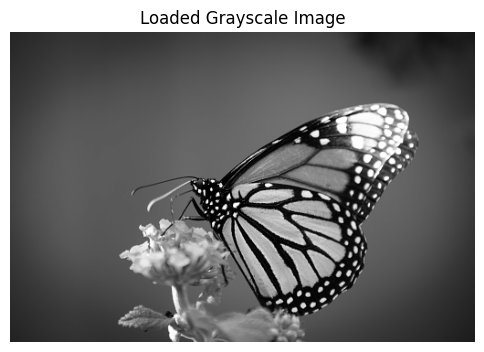

Edge detection algorithms applied.


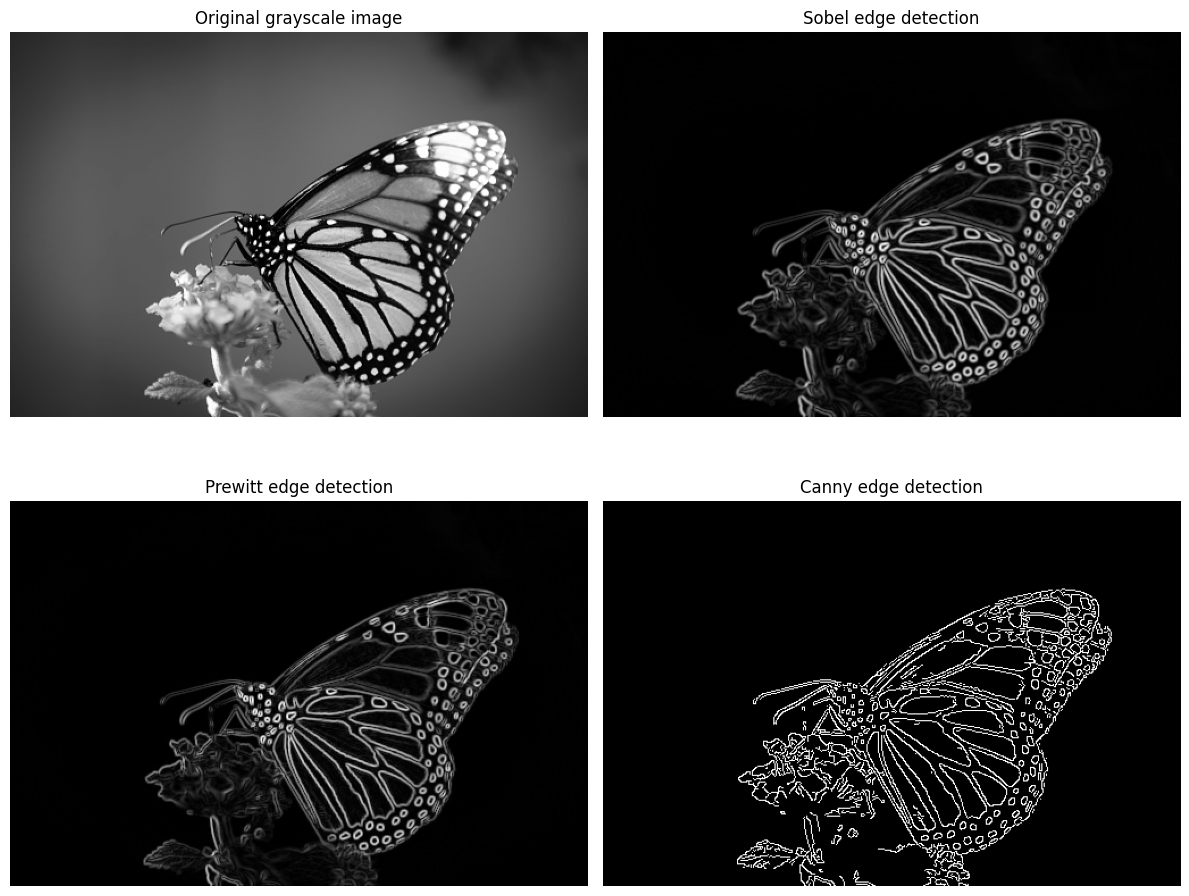

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show_comparison(original, sobel, prewitt, canny):
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original grayscale image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(sobel, cmap='gray')
    plt.title('Sobel edge detection')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(prewitt, cmap='gray')
    plt.title('Prewitt edge detection')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(canny, cmap='gray')
    plt.title('Canny edge detection')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


image_path = '/content/butter12.jpg'

image_grayscale = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image_grayscale is None:
    print("Error: Could not load image. Check the image path.")
else:

    original_gray = image_grayscale

    plt.figure(figsize=(6, 6))
    plt.imshow(original_gray, cmap='gray')
    plt.title('Loaded Grayscale Image')
    plt.axis('off')
    plt.show()

    # Sobel Edge Detection
    sobelx = cv2.Sobel(original_gray, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(original_gray, cv2.CV_64F, 0, 1, ksize=5)

    sobel_edges = np.sqrt(sobelx**2 + sobely**2)

    sobel_edges = cv2.normalize(
        sobel_edges, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Prewitt Edge Detection
    kernelx = np.array([
        [1, 0, -1],
        [1, 0, -1],
        [1, 0, -1]
    ], dtype=np.float64)

    kernely = np.array([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1]
    ], dtype=np.float64)

    prewittx = cv2.filter2D(
        original_gray, cv2.CV_64F, kernelx
    )

    prewitty = cv2.filter2D(
        original_gray, cv2.CV_64F, kernely
    )

    prewitt_edges = np.sqrt(
        prewittx**2 + prewitty**2
    )

    prewitt_edges = cv2.normalize(
        prewitt_edges, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Canny Edge Detection
    canny_edges = cv2.Canny(
        original_gray, 100, 200
    )

    print("Edge detection algorithms applied.")

    show_comparison(
        original_gray,
        sobel_edges,
        prewitt_edges,
        canny_edges
    )